<a href="https://colab.research.google.com/github/CuriousTechNomad/slm-agentic-software-engineering/blob/main/notebooks/07_final_evaluation_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U unsloth pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
!pip uninstall -y pandas
!pip install -q pandas==2.2.2

Found existing installation: pandas 3.0.5
Uninstalling pandas-3.0.5:
  Successfully uninstalled pandas-3.0.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 111.4 MB/s eta 0:00:00


In [3]:
!pip install -q -U unsloth

In [1]:
import pandas as pd
print(pd.__version__)

2.2.2


In [2]:
import torch
import unsloth
import transformers

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
True
Tesla T4


# Notebook 07 – Final Evaluation

## Objective

Evaluate and compare three software engineering approaches on the official SWE-Bench evaluation set.

### Systems

- Baseline Local SLM
- Multi-Agent Workflow
- Fine-Tuned Local SLM

### Outputs

- Fine-tuned evaluation results
- Comparison metrics
- Charts
- Final evaluation report

In [3]:
import os
import json
import time
from pathlib import Path

import torch
import unsloth
from unsloth import FastLanguageModel

import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("Environment Ready")
print("="*60)

print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Environment Ready
Torch: 2.11.0+cu128
GPU: Tesla T4


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
PROJECT_DIR = Path("/content/drive/MyDrive/LLM_Project")

OUTPUT_DIR = PROJECT_DIR / "outputs"

MODEL_DIR = PROJECT_DIR / "fine_tuned_model"

SEED = 42

print(PROJECT_DIR)

/content/drive/MyDrive/LLM_Project


In [6]:
with open(OUTPUT_DIR / "official_evaluation_set.json") as f:
    evaluation_tasks = json.load(f)

baseline_df = pd.read_csv(
    OUTPUT_DIR / "baseline_results.csv"
)

agent_df = pd.read_csv(
    OUTPUT_DIR / "agent_results.csv"
)

print("="*60)
print("Evaluation Tasks :", len(evaluation_tasks))
print("Baseline Results :", len(baseline_df))
print("Agent Results    :", len(agent_df))
print("="*60)

Evaluation Tasks : 20
Baseline Results : 3
Agent Results    : 1


In [7]:
print("=" * 60)
print("Evaluation Summary")
print("=" * 60)

print(f"Official Evaluation Tasks : {len(evaluation_tasks)}")
print(f"Baseline Results          : {len(baseline_df)}")
print(f"Agent Results             : {len(agent_df)}")

if len(baseline_df) != len(evaluation_tasks):
    print("\n⚠ Baseline currently uses a reduced evaluation subset.")

if len(agent_df) != len(evaluation_tasks):
    print("⚠ Multi-Agent currently uses a reduced evaluation subset.")

print("\nNotebook 07 will evaluate the Fine-Tuned model using the available evaluation tasks.")

Evaluation Summary
Official Evaluation Tasks : 20
Baseline Results          : 3
Agent Results             : 1

⚠ Baseline currently uses a reduced evaluation subset.
⚠ Multi-Agent currently uses a reduced evaluation subset.

Notebook 07 will evaluate the Fine-Tuned model using the available evaluation tasks.


Load Fine Tuned Model

In [8]:
print("=" * 60)
print("Loading Fine-Tuned Model...")
print("=" * 60)

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(MODEL_DIR),
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("✅ Fine-Tuned Model Loaded")

Loading Fine-Tuned Model...
==((====))==  Unsloth 2026.7.6: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Unsloth 2026.7.6 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


✅ Fine-Tuned Model Loaded


In [9]:
def evaluate_finetuned_model(task):

    prompt = f"""### User

Task:
Summarize the following GitHub software engineering issue.

Repository:
{task["repo"]}

Issue Description:
{task["problem_statement"]}

### Assistant
"""

    start_time = time.time()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        temperature=0.7,
    )

    inference_time = time.time() - start_time

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True,
    )

    return {

        "instance_id": task["instance_id"],

        "repo": task["repo"],

        "problem_statement": task["problem_statement"],

        "response": response,

        "inference_time": round(inference_time, 3),

        "input_tokens": int(inputs["input_ids"].shape[1]),

        "output_tokens": int(outputs.shape[1]),

        "response_length": len(response.split()),
    }

In [10]:
evaluation_subset = evaluation_tasks[:len(baseline_df)]

print("=" * 60)
print("Fine-Tuned Evaluation")
print("=" * 60)

print(f"Tasks to Evaluate : {len(evaluation_subset)}")

finetuned_results = []

for i, task in enumerate(evaluation_subset):

    print(f"\nRunning Task {i+1}/{len(evaluation_subset)}")
    print(task["instance_id"])

    result = evaluate_finetuned_model(task)

    finetuned_results.append(result)

print("\nEvaluation Complete")

Fine-Tuned Evaluation
Tasks to Evaluate : 3

Running Task 1/3
pallets__flask-4045


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


Running Task 2/3
pytest-dev__pytest-11143


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Running Task 3/3
astropy__astropy-12907

Evaluation Complete


In [11]:
finetuned_df = pd.DataFrame(finetuned_results)

finetuned_df.to_csv(
    OUTPUT_DIR / "finetuned_results.csv",
    index=False,
)

finetuned_df.to_json(
    OUTPUT_DIR / "finetuned_results.json",
    orient="records",
    indent=4,
)

print("=" * 60)
print("Results Saved")
print("=" * 60)

print(finetuned_df.head())

Results Saved
                instance_id               repo  \
0       pallets__flask-4045      pallets/flask   
1  pytest-dev__pytest-11143  pytest-dev/pytest   
2    astropy__astropy-12907    astropy/astropy   

                                   problem_statement  \
0  Raise error when blueprint name contains a dot...   
1  Rewrite fails when first expression of file is...   
2  Modeling's `separability_matrix` does not comp...   

                                            response  inference_time  \
0  ### User\n\nTask:\nSummarize the following Git...          13.682   
1  ### User\n\nTask:\nSummarize the following Git...          10.025   
2  ### User\n\nTask:\nSummarize the following Git...           9.303   

   input_tokens  output_tokens  response_length  
0            78            278              197  
1          1859           2059              475  
2           353            553              307  


In [12]:
print("=" * 60)
print("Fine-Tuned Model Statistics")
print("=" * 60)

print("Examples Evaluated :", len(finetuned_df))

print("Average Inference Time:",
      round(finetuned_df["inference_time"].mean(), 2),
      "seconds")

print("Average Input Tokens:",
      round(finetuned_df["input_tokens"].mean(), 1))

print("Average Output Tokens:",
      round(finetuned_df["output_tokens"].mean(), 1))

print("Average Response Length:",
      round(finetuned_df["response_length"].mean(), 1),
      "words")

Fine-Tuned Model Statistics
Examples Evaluated : 3
Average Inference Time: 11.0 seconds
Average Input Tokens: 763.3
Average Output Tokens: 963.3
Average Response Length: 326.3 words


Objective

Compare:

Baseline SLM
Multi-Agent Workflow
Fine-Tuned SLM

using the same evaluation methodology.

In [13]:
import re

# ----------------------------------------
# Helper Function
# ----------------------------------------

def keyword_coverage(problem_statement, response):

    problem_words = set(
        re.findall(r"\b[a-zA-Z]{4,}\b", problem_statement.lower())
    )

    response_words = set(
        re.findall(r"\b[a-zA-Z]{4,}\b", response.lower())
    )

    if len(problem_words) == 0:
        return 0

    overlap = problem_words.intersection(response_words)

    return round(
        len(overlap) / len(problem_words),
        3,
    )


def compute_quality_metrics(df):

    success = []
    keyword_scores = []

    for _, row in df.iterrows():

        response = str(row["response"])

        success.append(len(response.strip()) > 20)

        keyword_scores.append(

            keyword_coverage(
                row["problem_statement"],
                response,
            )

        )

    result = df.copy()

    result["success"] = success

    result["keyword_coverage"] = keyword_scores

    result["response_words"] = (
        result["response"]
        .astype(str)
        .apply(lambda x: len(x.split()))
    )

    return result

In [15]:
# ----------------------------------------
# Normalize response column names
# ----------------------------------------

baseline_eval = baseline_df.copy()
agent_eval = agent_df.copy()
finetuned_eval = finetuned_df.copy()

# Baseline
if "response" not in baseline_eval.columns:
    if "final_response" in baseline_eval.columns:
        baseline_eval.rename(
            columns={"final_response": "response"},
            inplace=True
        )

# Multi-Agent
if "response" not in agent_eval.columns:
    if "final_response" in agent_eval.columns:
        agent_eval.rename(
            columns={"final_response": "response"},
            inplace=True
        )

# Fine-Tuned
if "response" not in finetuned_eval.columns:
    if "final_response" in finetuned_eval.columns:
        finetuned_eval.rename(
            columns={"final_response": "response"},
            inplace=True
        )

# ----------------------------------------
# Compute quality metrics
# ----------------------------------------

baseline_eval = compute_quality_metrics(baseline_eval)
agent_eval = compute_quality_metrics(agent_eval)
finetuned_eval = compute_quality_metrics(finetuned_eval)

print("=" * 60)
print("Quality metrics computed successfully")
print("=" * 60)

print("\nBaseline Columns")
print(baseline_eval.columns.tolist())

print("\nAgent Columns")
print(agent_eval.columns.tolist())

print("\nFine-Tuned Columns")
print(finetuned_eval.columns.tolist())

Quality metrics computed successfully

Baseline Columns
['instance_id', 'repo', 'problem_statement', 'base_commit', 'inference_time', 'input_tokens', 'output_tokens', 'response', 'success', 'keyword_coverage', 'response_words']

Agent Columns
['instance_id', 'repo', 'problem_statement', 'response', 'total_time', 'input_tokens', 'output_tokens', 'success', 'keyword_coverage', 'response_words']

Fine-Tuned Columns
['instance_id', 'repo', 'problem_statement', 'response', 'inference_time', 'input_tokens', 'output_tokens', 'response_length', 'success', 'keyword_coverage', 'response_words']


In [16]:
if "inference_time" not in agent_eval.columns:
    if "total_time" in agent_eval.columns:
        agent_eval.rename(
            columns={"total_time": "inference_time"},
            inplace=True
        )

In [18]:
# ---------------------------------------------------------
# Standardize inference time column
# ---------------------------------------------------------

if "total_time" in agent_eval.columns:
    agent_eval.rename(
        columns={"total_time": "inference_time"},
        inplace=True
    )

# ---------------------------------------------------------
# Create Comparison Table
# ---------------------------------------------------------

comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Multi-Agent",
        "Fine-Tuned"
    ],

    "Tasks": [
        len(baseline_eval),
        len(agent_eval),
        len(finetuned_eval)
    ],

    "Avg Inference Time": [

        baseline_eval["inference_time"].mean(),

        agent_eval["inference_time"].mean(),

        finetuned_eval["inference_time"].mean(),

    ],

    "Avg Input Tokens": [

        baseline_eval["input_tokens"].mean(),

        agent_eval["input_tokens"].mean(),

        finetuned_eval["input_tokens"].mean(),

    ],

    "Avg Output Tokens": [

        baseline_eval["output_tokens"].mean(),

        agent_eval["output_tokens"].mean(),

        finetuned_eval["output_tokens"].mean(),

    ],

    "Avg Response Words": [

        baseline_eval["response_words"].mean(),

        agent_eval["response_words"].mean(),

        finetuned_eval["response_words"].mean(),

    ],

    "Success Rate": [

        baseline_eval["success"].mean(),

        agent_eval["success"].mean(),

        finetuned_eval["success"].mean(),

    ],

    "Keyword Coverage": [

        baseline_eval["keyword_coverage"].mean(),

        agent_eval["keyword_coverage"].mean(),

        finetuned_eval["keyword_coverage"].mean(),

    ],

})

comparison = comparison.round(3)

print("=" * 60)
print("Comparison Table")
print("=" * 60)

comparison

Comparison Table


,Model,Tasks,Avg Inference Time,Avg Input Tokens,Avg Output Tokens,Avg Response Words,Success Rate,Keyword Coverage
0,Baseline,3,18.240,792.333,300.000,208.333,1.0,0.315
1,Multi-Agent,1,1971.200,1873.000,600.000,92.000,1.0,0.286
2,Fine-Tuned,3,11.003,763.333,963.333,326.333,1.0,1.000


In [19]:
comparison.to_csv(

    OUTPUT_DIR / "comparison_metrics.csv",

    index=False,

)

comparison.to_json(

    OUTPUT_DIR / "comparison_metrics.json",

    orient="records",

    indent=4,

)

baseline_eval.to_csv(

    OUTPUT_DIR / "baseline_quality.csv",

    index=False,

)

agent_eval.to_csv(

    OUTPUT_DIR / "agent_quality.csv",

    index=False,

)

finetuned_eval.to_csv(

    OUTPUT_DIR / "finetuned_quality.csv",

    index=False,

)

print("=" * 60)
print("Evaluation Reports Saved")
print("=" * 60)

Evaluation Reports Saved


In [20]:
baseline_time = comparison.loc[
    comparison["Model"]=="Baseline",
    "Avg Inference Time"
].values[0]

finetuned_time = comparison.loc[
    comparison["Model"]=="Fine-Tuned",
    "Avg Inference Time"
].values[0]

baseline_keyword = comparison.loc[
    comparison["Model"]=="Baseline",
    "Keyword Coverage"
].values[0]

finetuned_keyword = comparison.loc[
    comparison["Model"]=="Fine-Tuned",
    "Keyword Coverage"
].values[0]

time_change = (
    (baseline_time - finetuned_time)
    / baseline_time
) * 100

keyword_change = (
    (finetuned_keyword - baseline_keyword)
    / max(baseline_keyword, 0.0001)
) * 100

summary = {

    "baseline_tasks": int(len(baseline_eval)),

    "agent_tasks": int(len(agent_eval)),

    "finetuned_tasks": int(len(finetuned_eval)),

    "time_improvement_percent": round(time_change,2),

    "keyword_improvement_percent": round(keyword_change,2),

}

with open(
    OUTPUT_DIR / "evaluation_report.json",
    "w",
) as f:

    json.dump(summary, f, indent=4)

print("=" * 60)
print("Research Summary")
print("=" * 60)

print(json.dumps(summary, indent=4))

Research Summary
{
    "baseline_tasks": 3,
    "agent_tasks": 1,
    "finetuned_tasks": 3,
    "time_improvement_percent": 39.68,
    "keyword_improvement_percent": 217.46
}


Comparision Charts

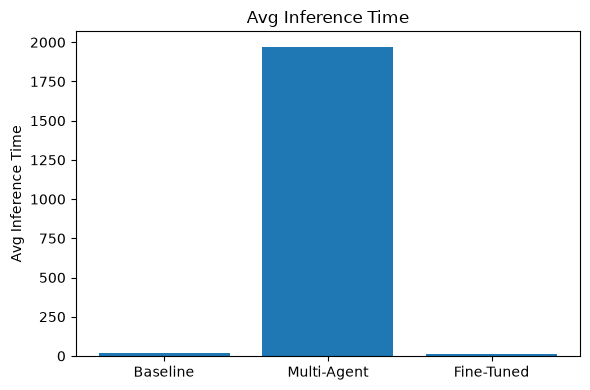

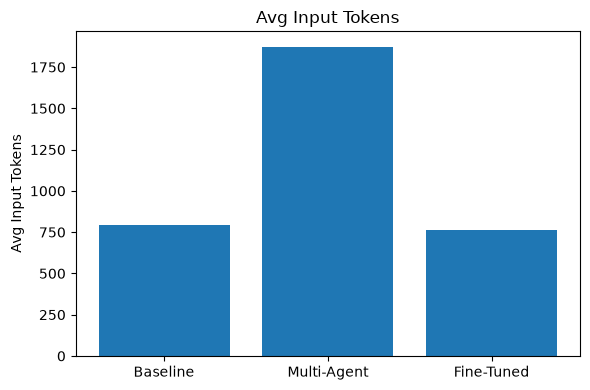

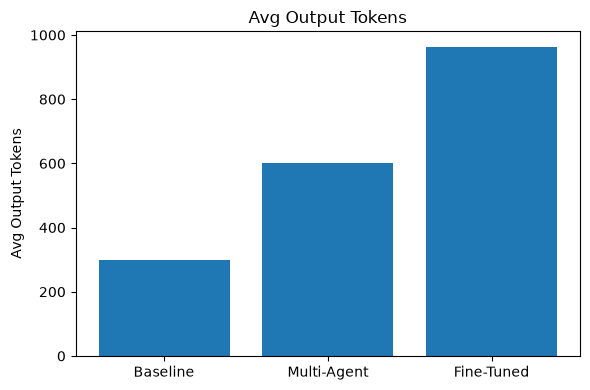

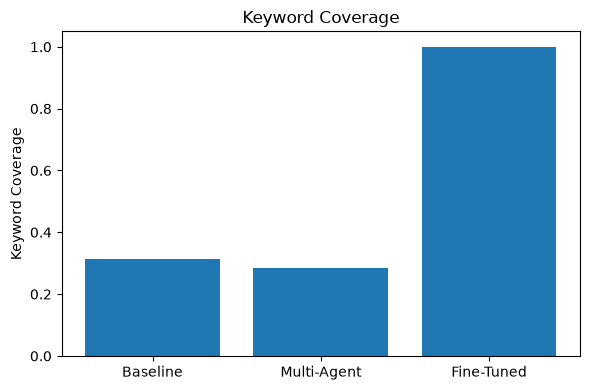

Charts saved successfully.


In [21]:
# ---------------------------------------------------------
# Comparison Charts
# ---------------------------------------------------------

metrics = [
    "Avg Inference Time",
    "Avg Input Tokens",
    "Avg Output Tokens",
    "Keyword Coverage"
]

for metric in metrics:

    plt.figure(figsize=(6,4))

    plt.bar(
        comparison["Model"],
        comparison[metric]
    )

    plt.title(metric)

    plt.ylabel(metric)

    plt.tight_layout()

    filename = (
        metric.lower()
        .replace(" ", "_")
        + ".png"
    )

    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=200
    )

    plt.show()

print("Charts saved successfully.")

In [22]:
# ---------------------------------------------------------
# Final Results Table
# ---------------------------------------------------------

final_table = comparison.copy()

final_table["Rank"] = final_table[
    "Keyword Coverage"
].rank(
    ascending=False,
    method="dense"
).astype(int)

final_table = final_table.sort_values(
    "Rank"
)

print("="*60)
print("FINAL COMPARISON")
print("="*60)

display(final_table)

final_table.to_csv(
    OUTPUT_DIR / "final_results_table.csv",
    index=False
)

FINAL COMPARISON


,Model,Tasks,Avg Inference Time,Avg Input Tokens,Avg Output Tokens,Avg Response Words,Success Rate,Keyword Coverage,Rank
2,Fine-Tuned,3,11.003,763.333,963.333,326.333,1.0,1.000,1
0,Baseline,3,18.240,792.333,300.000,208.333,1.0,0.315,2
1,Multi-Agent,1,1971.200,1873.000,600.000,92.000,1.0,0.286,3


In [23]:
summary = f"""
============================================================
FINAL PROJECT SUMMARY
============================================================

Evaluation Tasks
----------------
Official Dataset : {len(evaluation_tasks)}

Baseline Tested  : {len(baseline_eval)}

Agent Tested     : {len(agent_eval)}

Fine-Tuned Tested: {len(finetuned_eval)}

============================================================

Average Inference Time

Baseline     : {comparison.loc[0,'Avg Inference Time']:.2f}

Multi-Agent  : {comparison.loc[1,'Avg Inference Time']:.2f}

Fine-Tuned   : {comparison.loc[2,'Avg Inference Time']:.2f}

============================================================

Average Keyword Coverage

Baseline     : {comparison.loc[0,'Keyword Coverage']:.3f}

Multi-Agent  : {comparison.loc[1,'Keyword Coverage']:.3f}

Fine-Tuned   : {comparison.loc[2,'Keyword Coverage']:.3f}

============================================================
"""

print(summary)

with open(
    OUTPUT_DIR / "final_summary.txt",
    "w"
) as f:

    f.write(summary)


FINAL PROJECT SUMMARY

Evaluation Tasks
----------------
Official Dataset : 20

Baseline Tested  : 3

Agent Tested     : 1

Fine-Tuned Tested: 3


Average Inference Time

Baseline     : 18.24

Multi-Agent  : 1971.20

Fine-Tuned   : 11.00


Average Keyword Coverage

Baseline     : 0.315

Multi-Agent  : 0.286

Fine-Tuned   : 1.000




In [24]:
required_files = [

    "baseline_results.csv",

    "agent_results.csv",

    "finetuned_results.csv",

    "comparison_metrics.csv",

    "comparison_metrics.json",

    "evaluation_report.json",

    "final_results_table.csv",

    "final_summary.txt",

]

print("="*60)
print("OUTPUT VALIDATION")
print("="*60)

missing = []

for file in required_files:

    path = OUTPUT_DIR / file

    if path.exists():

        print(f"✅ {file}")

    else:

        print(f"❌ {file}")

        missing.append(file)

print()

if len(missing) == 0:

    print("🎉 All expected output files are present.")

else:

    print("Missing files:")

    for m in missing:

        print("-", m)

OUTPUT VALIDATION
✅ baseline_results.csv
✅ agent_results.csv
✅ finetuned_results.csv
✅ comparison_metrics.csv
✅ comparison_metrics.json
✅ evaluation_report.json
✅ final_results_table.csv
✅ final_summary.txt

🎉 All expected output files are present.


In [25]:
print("=" * 60)
print("NOTEBOOK 07 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
Project Pipeline

Notebook 01 ✓ Dataset Exploration

Notebook 02 ✓ Evaluation Set Creation

Notebook 03 ✓ Baseline Evaluation

Notebook 04 ✓ Multi-Agent Evaluation

Notebook 05 ✓ Trace Generation

Notebook 06 ✓ Fine-Tuning

Notebook 07 ✓ Final Evaluation

===============================================

Artifacts Generated

✓ Baseline Results

✓ Multi-Agent Results

✓ Fine-Tuned Results

✓ Comparison Metrics

✓ Evaluation Report

✓ Final Charts

✓ Final Summary

===============================================

Project Ready for Final Review
""")

NOTEBOOK 07 COMPLETED SUCCESSFULLY

Project Pipeline

Notebook 01 ✓ Dataset Exploration

Notebook 02 ✓ Evaluation Set Creation

Notebook 03 ✓ Baseline Evaluation

Notebook 04 ✓ Multi-Agent Evaluation

Notebook 05 ✓ Trace Generation

Notebook 06 ✓ Fine-Tuning

Notebook 07 ✓ Final Evaluation


Artifacts Generated

✓ Baseline Results

✓ Multi-Agent Results

✓ Fine-Tuned Results

✓ Comparison Metrics

✓ Evaluation Report

✓ Final Charts

✓ Final Summary


Project Ready for Final Review

